___

<a href='https://www.udemy.com/user/joseportilla/'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Support Vector Machines
## SVM - Regression

The concrete slump test measures the consistency of fresh concrete before it sets. It is performed to check the workability of freshly made concrete, and therefore the ease with which concrete flows. It can also be used as an indicator of an improperly mixed batch.

<img src="Types_of_concrete_slump.jpg">

Our data set consists of various cement properties and the resulting slump test metrics in cm. Later on the set concrete is tested for its compressive strength 28 days later.

Input variables (7)(component kg in one M^3 concrete):
* Cement
* Slag
* Fly ash
* Water
* SP
* Coarse Aggr.
* Fine Aggr.

Output variables (3):
* SLUMP (cm)
* FLOW (cm)
* **28-day Compressive Strength (Mpa)**

Data Source: https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test

*Credit: Yeh, I-Cheng, "Modeling slump flow of concrete using second-order regressions and artificial neural networks," Cement and Concrete Composites, Vol.29, No. 6, 474-480, 2007.*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/cement_slump.csv')

In [3]:
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


In [4]:
df.corr()['Compressive Strength (28-day)(Mpa)']

Cement                                0.445656
Slag                                 -0.331522
Fly ash                               0.444380
Water                                -0.254320
SP                                   -0.037909
Coarse Aggr.                         -0.160610
Fine Aggr.                           -0.154532
SLUMP(cm)                            -0.223499
FLOW(cm)                             -0.124189
Compressive Strength (28-day)(Mpa)    1.000000
Name: Compressive Strength (28-day)(Mpa), dtype: float64

<Axes: >

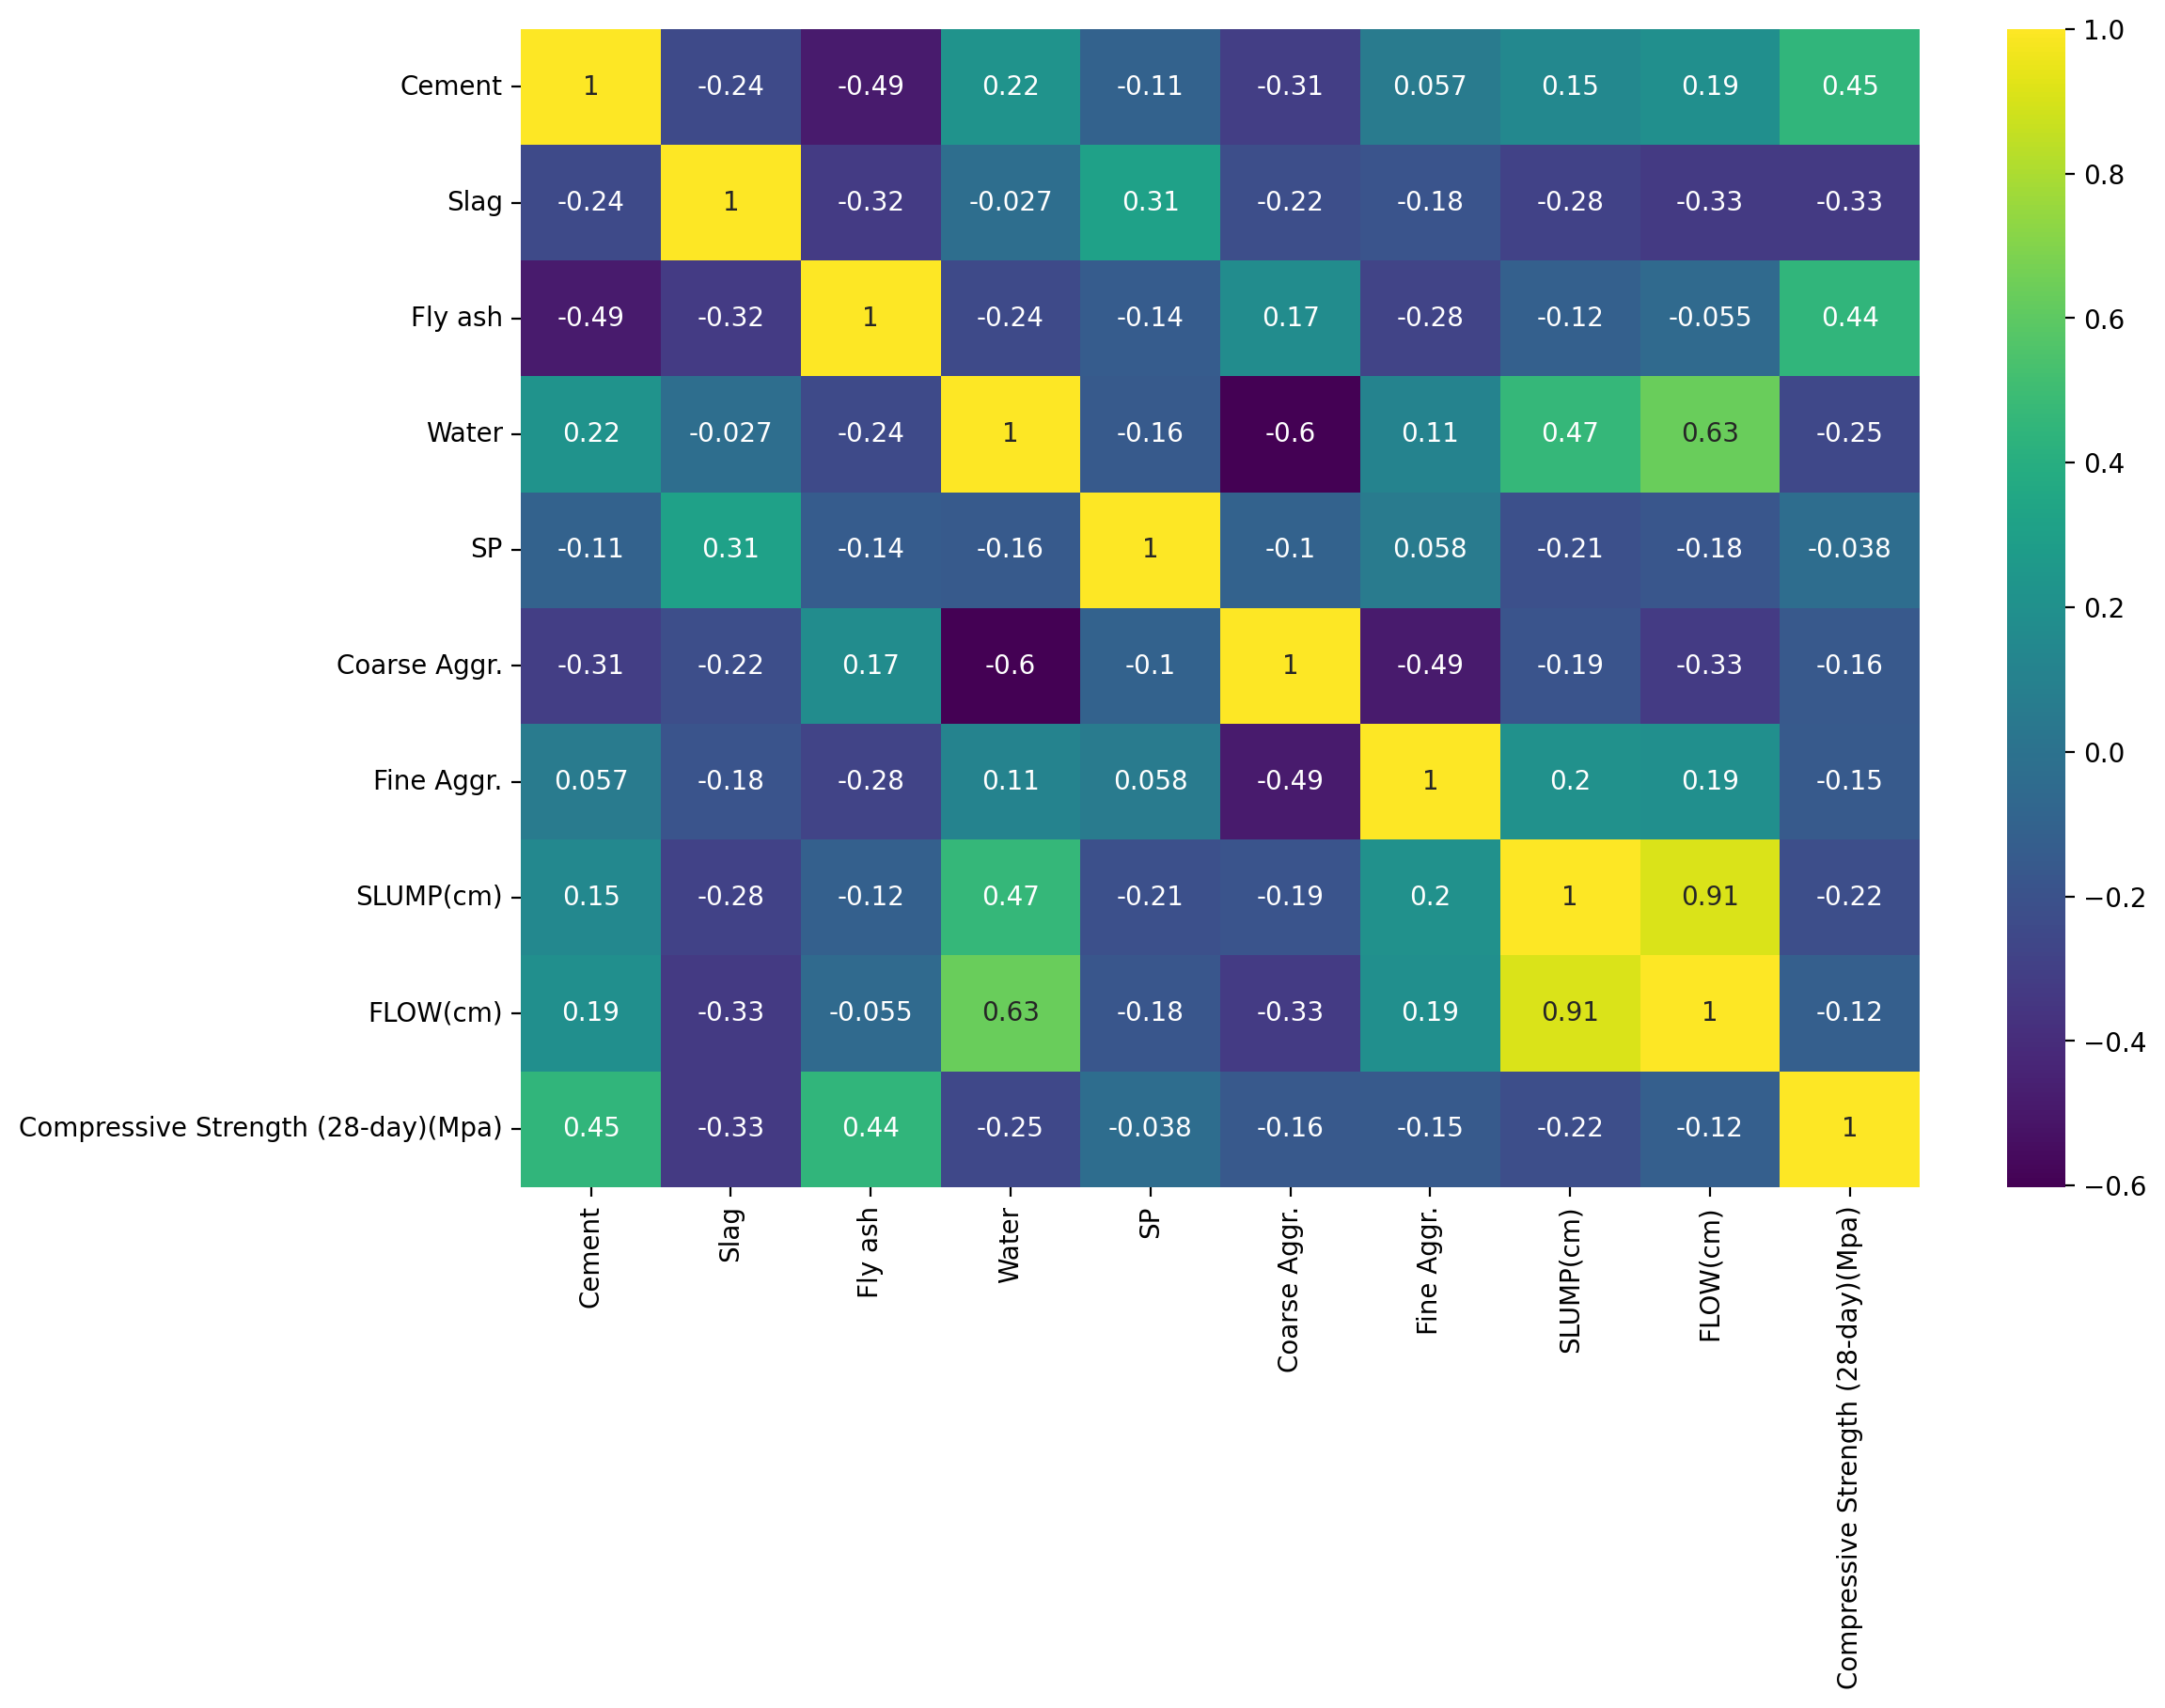

In [5]:
plt.figure(figsize=(12,8), dpi=200)
sns.heatmap(df.corr(),cmap='viridis',annot=True)

## Train | Test Split

Alternatively you could also set this up as a pipline, something like:

    >>> from sklearn.pipeline import make_pipeline
    >>> from sklearn.preprocessing import StandardScaler
    >>> from sklearn.svm import SVR

    >>> clf = make_pipeline(StandardScaler(), SVR())

In [7]:
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='str')

In [8]:
X = df.drop('Compressive Strength (28-day)(Mpa)',axis=1)
y = df['Compressive Strength (28-day)(Mpa)']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [11]:
from sklearn.preprocessing import StandardScaler
# Now what's absolutely key here is recall that support vector machines really looks at the feature space, and with the use of kernels we could be expanding this feature space as well.
# Whenever you're dealing with any sort of machine learning algorithm that really starts to look at the geometries of the future space, you wanna make sure that you scale your data. So we're gonna use the standard scaler to scale our data, and then we're gonna fit it to our training data and transform both our training and testing data.
# If you're not sure if your algorithm is going to be affected by it, you might as well just scale it anyways since it won't negatively harm your model.
# So for support vector machines, it's really recommended that you scale your data first.

In [12]:
scaler = StandardScaler()

In [13]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Support Vector Machines - Regression

There are three different implementations of Support Vector Regression: SVR, NuSVR and LinearSVR. LinearSVR provides a faster implementation than SVR but only considers the linear kernel, while NuSVR implements a slightly different formulation than SVR and LinearSVR. See [Implementation details](https://scikit-learn.org/stable/modules/svm.html#svm-implementation-details) for further details.

In [ ]:
from sklearn.svm import SVR,LinearSVR
# LinearSVR provides a faster implementation compared to SVR when using a linear kernel. So if you already know that you're gonna be using a linear kernel, you should use linear SVR because matematically it can perform a faster computation than just the normal SVR.
# LinearSVR is a linear support vector regression model that uses a linear kernel to fit the data. It is suitable for cases where the relationship between the features and the target variable is approximately linear. 
# SVR, on the other hand, is a more general support vector regression model that can use different kernel functions (such as 'rbf', 'poly', etc.) to capture non-linear relationships in the data. 
# The choice between LinearSVR and SVR depends on the nature of the data and the underlying relationship between the features and the target variable. If you suspect a linear relationship, LinearSVR may be more appropriate, while SVR with a non-linear kernel may be better for capturing complex relationships.
# SVR is a more general support vector regression model that can use different kernel functions (such as 'rbf', 'poly', etc.) to capture non-linear relationships in the data. The choice between LinearSVR and SVR depends on the nature of the data and the underlying relationship between the features and the target variable. If you suspect a linear relationship, LinearSVR may be more appropriate, while SVR with a non-linear kernel may be better for capturing complex relationships.


Setting C: C is 1 by default and it’s a reasonable default choice. If you have a lot of noisy observations you should decrease it: decreasing C corresponds to more regularization.

LinearSVC and LinearSVR are less sensitive to C when it becomes large, and prediction results stop improving after a certain threshold. Meanwhile, larger C values will take more time to train, sometimes up to 10 times longer

Epsilon: https://stats.stackexchange.com/questions/259018/meaning-of-epsilon-in-svm-regression

In [17]:
help(SVR)

Help on class SVR in module sklearn.svm._classes:

class SVR(sklearn.base.RegressorMixin, sklearn.svm._base.BaseLibSVM)
 |  SVR(*, kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)
 |  
 |  Epsilon-Support Vector Regression.
 |  
 |  The free parameters in the model are C and epsilon.
 |  
 |  The implementation is based on libsvm. The fit time complexity
 |  is more than quadratic with the number of samples which makes it hard
 |  to scale to datasets with more than a couple of 10000 samples. For large
 |  datasets consider using :class:`~sklearn.svm.LinearSVR` or
 |  :class:`~sklearn.linear_model.SGDRegressor` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |  
 |  Read more in the :ref:`User Guide <svm_regression>`.
 |  
 |  Parameters
 |  ----------
 |  kernel : {'linear', 'poly', 'rbf', 'sigmoid', 'precomput

In [15]:
base_model = SVR()

In [16]:
base_model.fit(scaled_X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [18]:
base_preds = base_model.predict(scaled_X_test)

## Evaluation

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
mean_absolute_error(y_test,base_preds)

5.236902091259178

In [21]:
np.sqrt(mean_squared_error(y_test,base_preds))

np.float64(6.695914838327133)

In [22]:
y_test.mean()

np.float64(36.26870967741935)

## Grid Search in Attempt for Better Model

In [23]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1],
             'kernel':['linear','rbf','poly'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0,0.01,0.1,0.5,1,2]}

# The C parameter is a regularization parameter that controls the trade-off between achieving a low error on the training data and minimizing the model complexity. A smaller C value allows for a wider margin, while a larger C value aims to fit the training data more closely.
# The kernel parameter specifies the type of kernel function to be used in the SVR model. Common options include 'linear' for a linear kernel, 'rbf' for a radial basis function kernel, and 'poly' for a polynomial kernel. The choice of kernel can affect the model's ability to capture complex relationships in the data.
# The gamma parameter is a hyperparameter for certain kernel functions (like 'rbf' and 'poly') that defines how far the influence of a single training example reaches. A low gamma value means that the influence of a single training example is far-reaching, while a high gamma value means that the influence is more localized.
# The degree parameter is specific to the polynomial kernel and defines the degree of the polynomial function used to fit the data. A higher degree allows for a more complex model, while a lower degree results in a simpler model.
# The epsilon parameter defines the margin of tolerance where no penalty is given to errors. It specifies the width of the epsilon-insensitive tube around the predicted values. A smaller epsilon value allows for a tighter fit to the training data, while a larger epsilon value allows for more flexibility in the model.
# A value of 0 for epsilon means that the model will try to fit the training data as closely as possible causing overfitting, while a value greater than 0 allows for some tolerance in the predictions, which can help prevent overfitting and improve generalization to unseen data.


In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
svr = SVR()
grid = GridSearchCV(svr,param_grid=param_grid)

In [25]:
grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1], 'degree': [2, 3, 4],
                         'epsilon': [0, 0.01, 0.1, 0.5, 1, 2],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [26]:
grid.best_params_

{'C': 1, 'degree': 2, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}

In [27]:
grid_preds = grid.predict(scaled_X_test)

In [28]:
mean_absolute_error(y_test,grid_preds)

2.5128012210762365

In [29]:
np.sqrt(mean_squared_error(y_test,grid_preds))

3.178210305119858

Great improvement!